# Lab 3: Effect of L1, L2, and Elastic Net Regularization on Model Training

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss


## Load and Preprocess Dataset

In [ ]:

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## Utility Function

In [ ]:

def train_and_evaluate(model):
    model.fit(X_train, y_train)

    y_train_prob = model.predict_proba(X_train)
    y_val_prob = model.predict_proba(X_val)

    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_val, y_val_prob)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    weights = model.coef_[0]
    return train_loss, val_loss, train_acc, val_acc, weights


## Baseline Model

In [ ]:

baseline = LogisticRegression(penalty=None, solver='lbfgs', max_iter=500)
bl_train_loss, bl_val_loss, bl_train_acc, bl_val_acc, bl_weights = train_and_evaluate(baseline)

print("Baseline Validation Accuracy:", bl_val_acc)


Baseline Validation Accuracy: 0.9385964912280702


## L1 Regularization

In [ ]:

lambda_l1 = 1.0
l1_model = LogisticRegression(penalty='l1', C=1/lambda_l1, solver='saga', max_iter=500)

l1_train_loss, l1_val_loss, l1_train_acc, l1_val_acc, l1_weights = train_and_evaluate(l1_model)

l1_penalty = lambda_l1 * np.sum(np.abs(l1_weights))
l1_total_cost = l1_val_loss + l1_penalty
l1_zero_weights = np.sum(l1_weights == 0)

print("L1 Validation Accuracy:", l1_val_acc)
print("Zero Weights:", l1_zero_weights)


L1 Validation Accuracy: 0.9736842105263158
Zero Weights: 6


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## L2 Regularization

In [ ]:

lambda_l2 = 1.0
l2_model = LogisticRegression(penalty='l2', C=1/lambda_l2, solver='lbfgs', max_iter=500)

l2_train_loss, l2_val_loss, l2_train_acc, l2_val_acc, l2_weights = train_and_evaluate(l2_model)

l2_penalty = lambda_l2 * np.sum(l2_weights ** 2)
l2_total_cost = l2_val_loss + l2_penalty

print("L2 Validation Accuracy:", l2_val_acc)


L2 Validation Accuracy: 0.9736842105263158


## Elastic Net Regularization

In [ ]:

lambda_en = 1.0
l1_ratio = 0.5

elastic_model = LogisticRegression(
    penalty='elasticnet',
    C=1/lambda_en,
    l1_ratio=l1_ratio,
    solver='saga',
    max_iter=500
)

en_train_loss, en_val_loss, en_train_acc, en_val_acc, en_weights = train_and_evaluate(elastic_model)

en_penalty = lambda_en * (
    l1_ratio * np.sum(np.abs(en_weights)) +
    (1 - l1_ratio) * np.sum(en_weights ** 2)
)

en_total_cost = en_val_loss + en_penalty
en_zero_weights = np.sum(en_weights == 0)

print("Elastic Net Validation Accuracy:", en_val_acc)
print("Zero Weights:", en_zero_weights)


Elastic Net Validation Accuracy: 0.9736842105263158
Zero Weights: 5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Weight Distribution

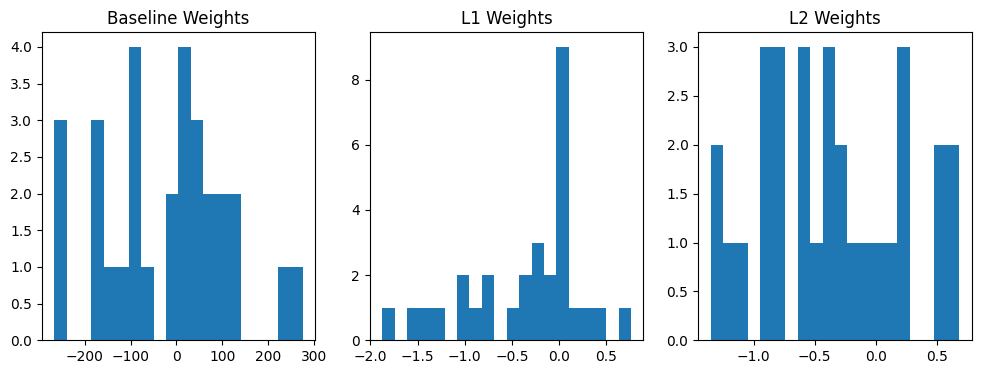

In [ ]:

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(bl_weights, bins=20)
plt.title("Baseline Weights")

plt.subplot(1,3,2)
plt.hist(l1_weights, bins=20)
plt.title("L1 Weights")

plt.subplot(1,3,3)
plt.hist(l2_weights, bins=20)
plt.title("L2 Weights")

plt.show()


## Advanced Task: Lambda Sensitivity

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


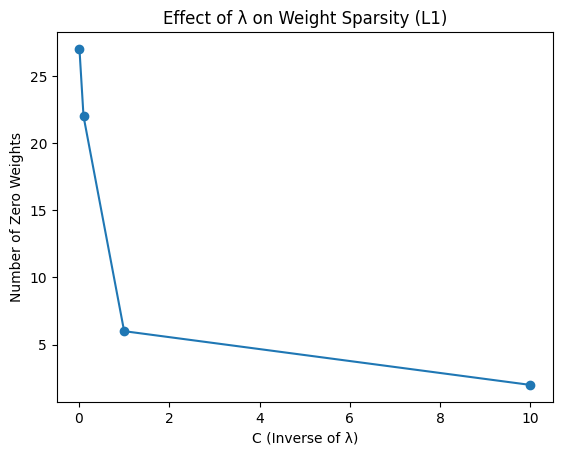

In [ ]:

C_values = [0.01, 0.1, 1, 10]
sparsity = []

for C in C_values:
    model = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=500)
    model.fit(X_train, y_train)
    sparsity.append(np.sum(model.coef_[0] == 0))

plt.plot(C_values, sparsity, marker='o')
plt.xlabel("C (Inverse of λ)")
plt.ylabel("Number of Zero Weights")
plt.title("Effect of λ on Weight Sparsity (L1)")
plt.show()


## Interpretation
The baseline model uses all features and may overfit the data.
L2 regularization reduces the magnitude of weights while retaining all features, improving stability.
L1 regularization removes less important features by driving some weights to zero.
Elastic Net combines both sparsity and weight shrinkage, balancing feature selection and stability.
Overall, regularization simplifies the model and improves generalization.